# 03 · 学一个世界模型，用它规划，再用新数据修复它

**研究问题：从随机轨迹学到的动力学，能否支持控制？让规划器采集新数据后，重训会更好吗？**

继续使用第二课的 Pendulum，把任务保持简单，集中理解方法的变化。
第二课直接学 $\pi(o)=a$；本课学 $f_\theta(o,a)\approx o'$，再通过搜索动作序列来控制系统。

完整闭环：`随机交互 → 动力学拟合 → 一步/多步诊断 → MPC 执行 → 新轨迹 → 对照重训 → 再评测 → 复盘`。
量化类比：先建立可用于情景推演的模型，再优化决策；决策走到的新区域又会暴露模型缺口。

这里“世界模型”指低维状态转移模型。奖励函数已知，网络只学动力学；不是图像生成、Dreamer 或 PETS 完整复现。

## 使用方式与交付物

```bash
uv run --locked --group notebooks jupyter lab notebooks/03_世界模型与规划迭代.ipynb
```
从项目目录执行。第一遍逐格跑，先预测结果，再看输出，预留 90–120 分钟理解与复盘。
你会得到原始 transition、四个动力学模型、同预算对照表、实际控制回放和规划耗时记录。
CPU 默认配置以小实验为目标，机器计算时间单独记录。

## 1 · 固定协议

控制器每 3 个环境步重新规划一次，即 150 ms；动作在这 3 步内保持不变。
预测 8 个动作块，就是 $8\times3\times0.05=1.2$ 秒的未来。每次只执行第一块，然后读新观测重新规划。

第一遍不追求最强分数。先确保你能解释这个过程，再改模型、时域或搜索预算。
**先预测**：一步预测误差最小的模型，闭环回报一定最高吗？新增规划器数据一定优于新增随机数据吗？

In [1]:
SEED = 7
N_TRAIN = 20
UPDATES = 1000
N_EXTRA = 8
N_EVAL = 8
PLAN = dict(horizon=8, candidates=48, iterations=2, repeat=3)
MY_PREDICTION = "待填写：我的预测是……因为……"

In [2]:
from pathlib import Path
import sys, time, copy
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "course_utils.py").exists()), None)
if ROOT is None:
    raise RuntimeError("请在完整 robot_learning_loops 目录内启动。")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import gymnasium as gym
import numpy as np
import pandas as pd
import torch
from IPython.display import display, Image, Markdown
from common import plt, summarize
from loop03_world_model import collect, Dynamics, CEMPlanner, known_transition, running_cost
from course_utils import (begin_notebook, audit_transitions, prediction_diagnostics,
                          collect_with_planner, reload_dynamics, paired_return, show_gif, write_review)
START = time.perf_counter()
OUT, manifest = begin_notebook("notebook03", "03_世界模型与规划迭代.ipynb",
    dict(seed=SEED, train_episodes=N_TRAIN, updates=UPDATES, extra_episodes=N_EXTRA,
         eval_episodes=N_EVAL, **PLAN))
display(pd.Series(manifest["versions"], name="installed_version").to_frame())
print("Planning horizon:", PLAN["horizon"]*PLAN["repeat"]*.05, "seconds")

Results: runs/notebook03-20260910-093403-308000
CPU threads: 2


,installed_version
numpy,2.5.3
torch,2.14.0
gymnasium,1.3.0
mujoco,3.12.0
stable-baselines3,2.9.0


Planning horizon: 1.2000000000000002 seconds


## 2 · 数据标签换成“动作后实际发生了什么”

输入是 $(o_t,a_t)$，标签是 $o_{t+1}-o_t$。训练时不需要专家动作，也不需要通过奖励更新 actor。
训练集由随机动作采集；验证集按完整 episode 分开，避免相邻帧泄漏。

先检查字段、连续性和单位。cos/sin 是无量纲，角速度是 rad/s，动作是力矩。
网络拟合标准化状态增量；输入和标签的统计量只从训练集估计。

In [3]:
train = collect(range(N_TRAIN))
val = collect(range(2000, 2010))
assert not set(train["episode"]) & set(val["episode"])
np.savez_compressed(OUT / "raw_train.npz", **train)
np.savez_compressed(OUT / "raw_validation.npz", **val)
display(pd.DataFrame([audit_transitions(train, require_closed=True),
                      audit_transitions(val, require_closed=True)], index=["train", "validation"]))
display(pd.DataFrame({"theta_velocity": train["obs"][:6, 2], "action": train["action"][:6, 0],
                      "next_velocity": train["next_obs"][:6, 2],
                      "delta_velocity": (train["next_obs"]-train["obs"])[:6, 2]}))

,rows,episodes,audit
train,4000,20,PASS
validation,2000,10,PASS


,theta_velocity,action,next_velocity,delta_velocity
0,-0.460427,0.547847,0.190404,0.650831
1,0.190404,-0.920853,0.625560,0.435155
2,0.625560,-1.836106,0.938269,0.312710
3,0.938269,-1.933890,1.257491,0.319221
4,1.257491,1.253081,2.081032,0.823541
5,2.081032,1.651022,3.002182,0.921150


## 3 · 写出动力学训练循环

网络结构为 `4 → 128 → 128 → 3`；4 维输入是观测加动作，3 维输出是标准化状态增量。
输出加回当前状态后，cos/sin 投影回单位圆，角速度限制在环境范围。这个物理先验减少无效观测，但不能保证动力学准确。

训练目标：标准化增量 MSE。验证目标：实际下一观测预测误差。两者尺度不同。
本课用固定更新预算，不按开发评测成绩选择 checkpoint。

In [4]:
inputs = np.concatenate([train["obs"], train["action"]], axis=1)
deltas = train["next_obs"] - train["obs"]
torch.manual_seed(SEED)
base = Dynamics(inputs.mean(0), np.maximum(inputs.std(0), .01),
                deltas.mean(0), np.maximum(deltas.std(0), .001))
print(base.net)

def train_dynamics(model, data, validation, updates, seed, phase):
    x, a, y = [torch.tensor(data[k], dtype=torch.float32) for k in ["obs", "action", "next_obs"]]
    vx, va, vy = [torch.tensor(validation[k], dtype=torch.float32) for k in ["obs", "action", "next_obs"]]
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    rng = np.random.default_rng(seed)
    records = []
    for step in range(updates):
        idx = rng.integers(0, len(x), 256)
        prediction = model.normalized_delta(x[idx], a[idx])
        target = (y[idx]-x[idx]-model.ym)/model.ys
        loss = (prediction-target).square().mean()
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        if step % max(1, updates//10) == 0 or step == updates-1:
            with torch.inference_mode():
                validation_loss = (model(vx, va)-vy).square().mean().item()
            records.append(dict(phase=phase, step=step+1, train_normalized_mse=loss.item(),
                                val_next_state_mse=validation_loss))
    model.eval()
    return records

history = train_dynamics(base, train, val, UPDATES, SEED, "base")
base = reload_dynamics(base, OUT, "base", val)
display(pd.DataFrame(history).iloc[[0, -1]])

Sequential(
  (0): Linear(in_features=4, out_features=128, bias=True)
  (1): Tanh()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): Tanh()
  (4): Linear(in_features=128, out_features=3, bias=True)
)


,phase,step,train_normalized_mse,val_next_state_mse
0,base,1,1.068865,0.084326
10,base,1000,0.001161,0.000018


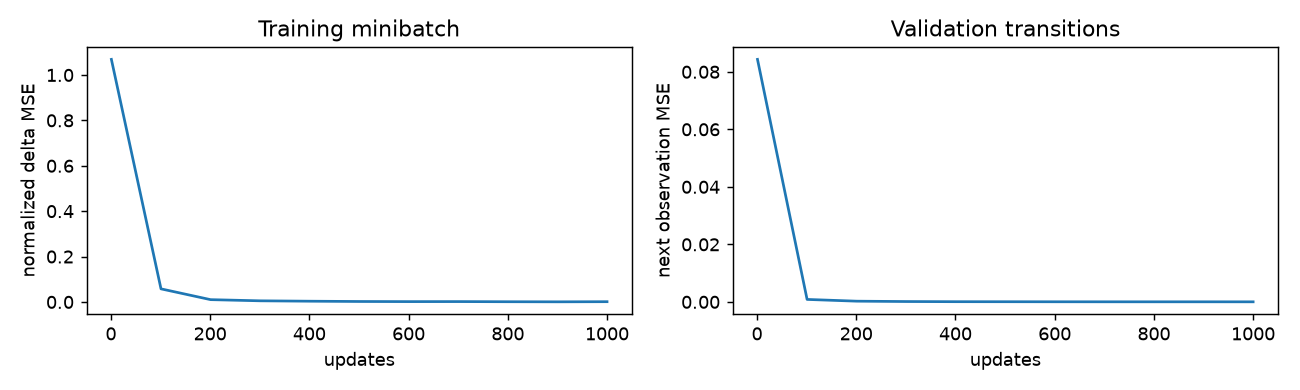

In [5]:
curve = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(curve.step, curve.train_normalized_mse)
axes[0].set(xlabel="updates", ylabel="normalized delta MSE", title="Training minibatch")
axes[1].plot(curve.step, curve.val_next_state_mse)
axes[1].set(xlabel="updates", ylabel="next observation MSE", title="Validation transitions")
fig.tight_layout(); fig.savefig(OUT / "dynamics_training.png", dpi=130); plt.close(fig)
display(Image(filename=str(OUT / "dynamics_training.png")))

## 4 · 一步准，不等于推演 25 步仍然准

把预测出的状态重新送入模型，使用验证轨迹中的同一串动作向前滚动；中途不喂入真实状态纠错。
每个预测窗口完全位于同一 episode 内。这个指标检验多步模型误差，不是闭环控制成绩。

总 state MSE 混合了不同单位，只作工程诊断；下面另外报告角度 RMSE（rad）和角速度 RMSE（rad/s）。
角度误差按周期 wrap，避免把接近 $-\pi$ 和 $\pi$ 的两个姿态当成相差约 $2\pi$。

,angle_rmse_rad,velocity_rmse_rad_s
horizon,,
1,0.0030,0.0051
5,0.0108,0.0223
10,0.0187,0.0521
25,0.0905,0.2652


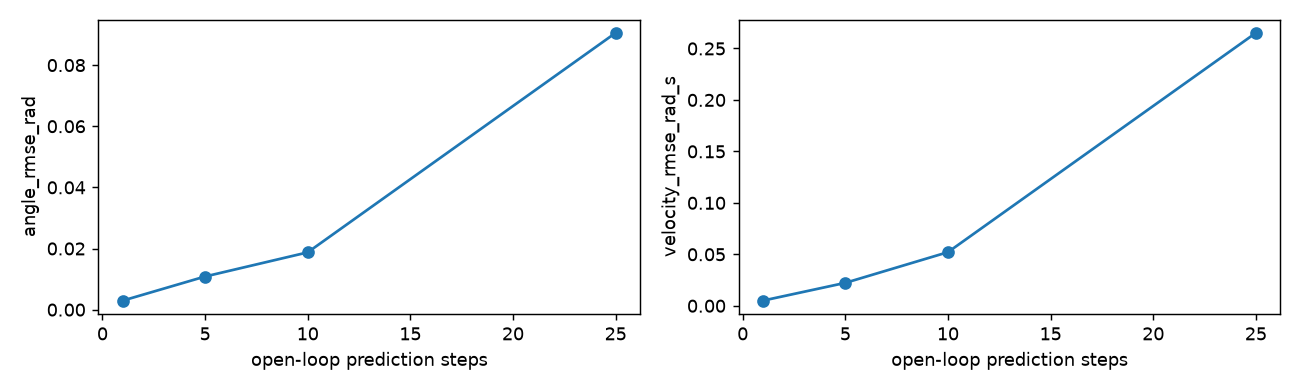

In [6]:
errors = prediction_diagnostics(base, val)
errors.to_csv(OUT / "base_multistep_error.csv", index=False)
display(errors.groupby("horizon")[["angle_rmse_rad", "velocity_rmse_rad_s"]].mean().round(4))
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, metric in zip(axes, ["angle_rmse_rad", "velocity_rmse_rad_s"]):
    errors.groupby("horizon")[metric].mean().plot(ax=ax, marker="o")
    ax.set(xlabel="open-loop prediction steps", ylabel=metric)
fig.tight_layout(); fig.savefig(OUT / "multistep_error.png", dpi=130); plt.close(fig)
display(Image(filename=str(OUT / "multistep_error.png")))

## 5 · 用模型选动作：CEM 和 MPC 各做什么？

CEM 在这里是一个动作序列搜索器：采样多条候选序列 → 用模型推演每条序列的成本 → 保留成本较低的候选 → 更新采样分布 → 再搜索。
MPC 是执行方式：取搜索结果的第一段动作去执行，然后根据**模拟器的新观测**重新规划。

本课成本函数与环境负奖励相同，是已知函数；我们只学状态转移。
下面用随机候选序列做一次可见的打分，随后使用完整 CEMPlanner 执行控制。

In [7]:
env = gym.make("Pendulum-v1")
initial, _ = env.reset(seed=10000)
env.close()
generator = torch.Generator().manual_seed(SEED)
candidates = torch.rand(48, PLAN["horizon"], 1, generator=generator)*4-2
with torch.inference_mode():
    imagined = torch.tensor(initial, dtype=torch.float32).repeat(48, 1)
    costs = torch.zeros(48)
    for h in range(PLAN["horizon"]):
        for _ in range(PLAN["repeat"]):
            costs += running_cost(imagined, candidates[:, h])
            imagined = base(imagined, candidates[:, h])
display(pd.DataFrame({"candidate": range(48), "predicted_cost": costs.numpy(),
                      "first_torque": candidates[:, 0, 0].numpy()}).sort_values("predicted_cost").head(6))
print("Actual CEM first action:", CEMPlanner(base, **PLAN, seed=SEED).action(initial))

,candidate,predicted_cost,first_torque
44,44,0.581445,-0.560775
43,43,1.150190,-1.429427
23,23,1.257864,-0.368450
13,13,1.737932,-0.395015
19,19,1.881079,-1.838857
39,39,3.646058,-1.485845


Actual CEM first action: [-0.71336323]


**停下来回答**：如果优化器找到了一条“模型以为很便宜，实际却很差”的序列，增加搜索候选一定有帮助吗？

## 6 · 第一轮部署：随机、已知方程、学到的模型

三者使用相同初始 seed 和动作保持周期。已知方程 MPC 仍受搜索预算与规划时域限制，不是全局最优上界。
所有数据标签取自实际 `env.step`；模型想象出的下一状态不会被伪装成真实训练标签。

这里与第二课 SAC 的默认动作频率不同；跨课回报不能直接用来给算法排榜。

,return,upright_fraction
policy,,
base_mpc,-139.159,0.842
known_mpc,-139.158,0.842
random,-1203.033,0.011



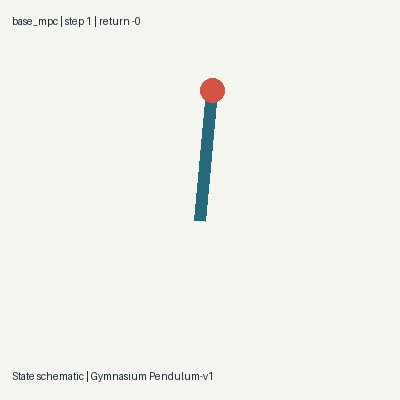

In [8]:
EVAL_SEEDS = list(range(10000, 10000+N_EVAL))
baseline_rows = []
for name, transition in [("random", None), ("known_mpc", known_transition), ("base_mpc", base)]:
    trajectory, scores = collect_with_planner(transition, name, EVAL_SEEDS, PLAN, OUT)
    audit_transitions(trajectory, require_closed=True)
    np.savez_compressed(OUT / f"evaluation_{name}.npz", **trajectory)
    baseline_rows += scores
display(pd.DataFrame(baseline_rows).groupby("policy")[["return", "upright_fraction"]].mean().round(3))
show_gif(OUT / "base_mpc.gif")

## 7 · 完成第二个闭环：模型驱动新数据采集

现在冻结第一轮模型，让它在**新的采集初始条件**下用 MPC 控制摆。把实际访问的状态、动作、真实下一状态收回来。
再从相同初始条件收集等量随机数据，保持相同动作频率。

| 组 | 新标签来源 | 追加更新 | 起点 |
|---|---|---:|---|
| more_updates | 无新增标签 | S | 同一个 base |
| more_random | 随机动作采集 | S | 同一个 base |
| planner_data | base 模型驱动的 MPC 采集 | S | 同一个 base |

初始训练数据每步换随机动作；本轮两种新增采集都每 3 步换动作，因此新增数据对照的控制频率一致。
归一化统计保持初始训练集不变；追加阶段都重建 Adam、使用相同 batch 和更新预算。

In [9]:
EXTRA_SEEDS = list(range(3000, 3000+N_EXTRA))
assert not set(EXTRA_SEEDS) & (set(EVAL_SEEDS) | set(train["episode"]) | set(val["episode"]))
planner_data, _ = collect_with_planner(base, "collection_mpc", EXTRA_SEEDS, PLAN)
random_data, _ = collect_with_planner(None, "collection_random", EXTRA_SEEDS, PLAN)
assert len(planner_data["obs"]) == len(random_data["obs"])
for name, data in [("planner", planner_data), ("random", random_data)]:
    audit_transitions(data, require_closed=True)
    np.savez_compressed(OUT / f"raw_extra_{name}.npz", **data)
coverage = []
for name, data in [("initial", train), ("extra_random", random_data), ("extra_planner", planner_data)]:
    angle = np.arctan2(data["obs"][:, 1], data["obs"][:, 0])
    coverage.append(dict(data=name, labels=len(angle),
        fraction_near_upright=float(np.mean((np.abs(angle)<.2) & (np.abs(data["obs"][:, 2])<1)))))
display(pd.DataFrame(coverage))
print("State coverage differences are descriptive; improvement still requires controlled evaluation.")

,data,labels,fraction_near_upright
0,initial,4000,0.006250
1,extra_random,1600,0.031875
2,extra_planner,1600,0.783125


State coverage differences are descriptive; improvement still requires controlled evaluation.


In [10]:
models = {"base_mpc": base}
for name, addition in [("more_updates", None), ("more_random", random_data), ("planner_data", planner_data)]:
    data = train if addition is None else {k: np.concatenate([train[k], addition[k]]) for k in train}
    model = copy.deepcopy(base)
    history += train_dynamics(model, data, val, UPDATES, SEED+1, name)
    models[name] = reload_dynamics(model, OUT, name, val)
pd.DataFrame(history).to_csv(OUT / "training.csv", index=False)
print("All models reloaded from saved weights.")

All models reloaded from saved weights.


## 8 · 对照复评：模型更准、控制更好、计算更快是三件事

所有训练已经完成，下面评测各组。先看总体回报，再看“保持向上比例”和规划 p95 耗时。
记录的耗时只覆盖规划调用，不包含真实传感器、传输、驱动和调度；低于 150 ms 也不能证明真机实时性。

新增规划器数据未必取胜：小环境可能已经容易拟合；也可能数据集中在少数状态，削弱其他区域的精度。保留负结果，别为了漂亮结论改评测集合。

      policy       condition  n         mean       ci_low      ci_high
      random action_repeat_3  8 -1203.033187 -1331.882404 -1050.663225
   known_mpc action_repeat_3  8  -139.157566  -187.292695   -90.781561
    base_mpc action_repeat_3  8  -139.159125  -187.414967   -91.624618
more_updates action_repeat_3  8  -139.307136  -187.516367   -91.404176
 more_random action_repeat_3  8  -139.292352  -187.805826   -91.724005
planner_data action_repeat_3  8  -138.964426  -186.721964   -91.871263


,return,upright_fraction,planning_p95_ms
policy,,,
base_mpc,-139.159,0.842,3.792
known_mpc,-139.158,0.842,0.762
more_random,-139.292,0.848,3.734
more_updates,-139.307,0.846,3.738
planner_data,-138.964,0.847,3.719
random,-1203.033,0.011,0.001


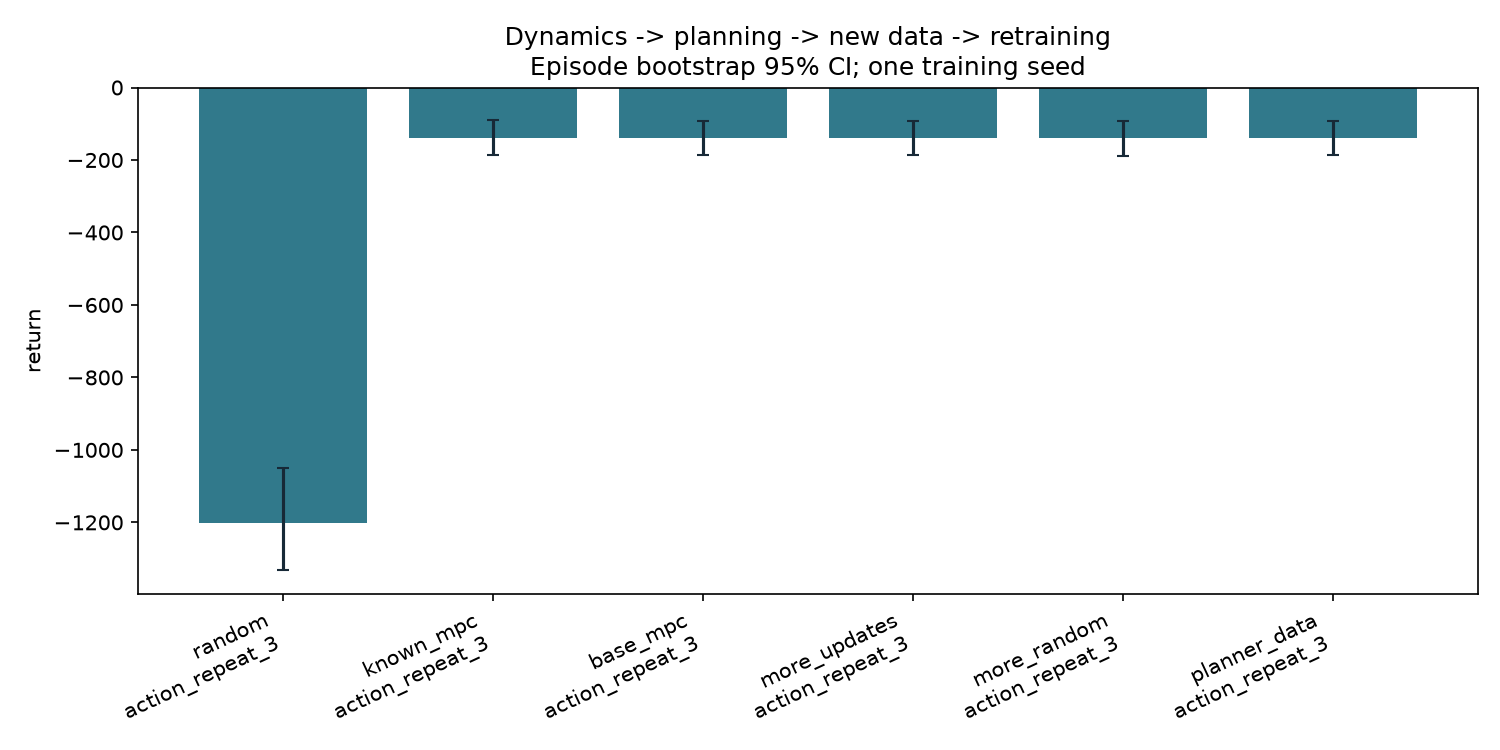

,candidate,reference,condition,mean_delta,ci_low,ci_high,n_pairs
0,planner_data,base_mpc,action_repeat_3,0.195,-0.009,0.407,8
1,planner_data,more_updates,action_repeat_3,0.343,0.123,0.628,8
2,planner_data,more_random,action_repeat_3,0.328,0.060,0.614,8


In [11]:
rows = list(baseline_rows)
for name, model in models.items():
    if name != "base_mpc":
        trajectory, scores = collect_with_planner(model, name, EVAL_SEEDS, PLAN, OUT)
        np.savez_compressed(OUT / f"evaluation_{name}.npz", **trajectory)
        rows += scores
frame = summarize(rows, OUT, "return", "Dynamics -> planning -> new data -> retraining")
display(frame.groupby("policy")[["return", "upright_fraction", "planning_p95_ms"]].mean().round(3))
display(Image(filename=str(OUT / "comparison.png")))
paired = pd.concat([paired_return(frame, "planner_data", ref)
                    for ref in ["base_mpc", "more_updates", "more_random"]], ignore_index=True)
paired.to_csv(OUT / "controlled_paired_deltas.csv", index=False)
display(paired.round(3))

,angle_rmse_rad,velocity_rmse_rad_s,return,upright_fraction
policy,,,,
planner_data,0.0912,0.2627,-138.9644,0.8469
base_mpc,0.0905,0.2652,-139.1591,0.8425
more_random,0.0894,0.2822,-139.2924,0.8481
more_updates,0.0673,0.2107,-139.3071,0.8456


**补规划器数据后：与第一轮同一个初始状态**


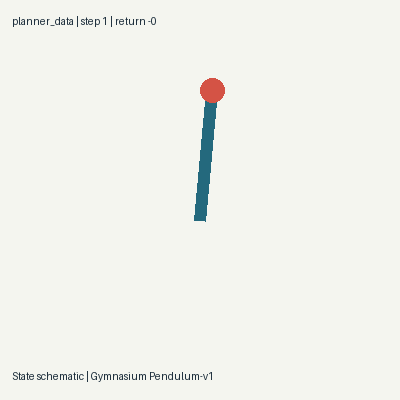

In [12]:
diagnostics = []
for name, model in models.items():
    error = prediction_diagnostics(model, val)
    error["policy"] = name
    diagnostics.append(error)
diagnostics = pd.concat(diagnostics, ignore_index=True)
diagnostics.to_csv(OUT / "all_multistep_errors.csv", index=False)
offline = diagnostics[diagnostics.horizon == 25].groupby("policy")[["angle_rmse_rad", "velocity_rmse_rad_s"]].mean()
online = frame.groupby("policy")[["return", "upright_fraction"]].mean()
display(offline.join(online).sort_values("return", ascending=False).round(4))
display(Markdown("**补规划器数据后：与第一轮同一个初始状态**"))
show_gif(OUT / "planner_data.gif")

## 9 · 复盘：把预测模型和决策系统分别讲清楚

先填写，再读 `03_参考复盘.md`。如果某组差异的区间跨 0，就如实写“这次评测不足以清晰区分”。
这里只做了单轮数据迭代、一个训练 seed 和少量开发 episodes；跨种子、未触碰测试集与跨任务泛化仍是下一步。

In [13]:
MY_REVIEW = {
    "本课学习的函数是什么？": "待填写：明确输入、标签、输出，以及已知的成本函数。",
    "CEM 与 MPC 分别负责什么？": "待填写：推演、搜索、执行和重规划各在哪里？",
    "新增数据有没有比多训练更好？": "待填写：引用配对差值与区间。",
    "离线模型误差与控制回报是否同序？": "待填写：用本次结果解释，不假设必然相关。",
    "下一轮只改什么？": "待填写：时域/搜索预算/模型集成/数据之一；写出判定标准。",
}
write_review(OUT, "世界模型与规划迭代复盘", MY_PREDICTION, MY_REVIEW, frame, time.perf_counter()-START)

Elapsed from setup: 15.1 seconds (includes reading time in an interactive run).
Saved: runs/notebook03-20260910-093403-308000/review.md


## 10 · 第二遍作业：从小实验走向研究

1. 固定其他配置，只改 horizon=4/8/12，记录多步预测误差、闭环回报与规划耗时。长时域是否总是更好？
2. 固定模型，只改 candidates=24/48/96。搜索更充分能否弥补模型偏差？
3. 固定开发协议，运行 seeds 7、11、19，再判断新增数据的效果是否稳定。
4. 下一阶段引入多个动力学模型，检查模型间分歧是否能帮助识别未知区域。分歧不自动等于校准的不确定性；要用实际误差验证。
5. 确定方法后冻结参数，另取未使用初始条件作最终评测；再考虑更复杂的 MuJoCo 任务。

## 知识地图与一手资料

- [Pendulum 环境合同](https://gymnasium.farama.org/environments/classic_control/pendulum/)：检查状态、动作、奖励与时间。
- [PETS 论文](https://arxiv.org/abs/1805.12114)：后续理解概率动力学集成和 trajectory sampling；本课单模型没有实现这些机制。
- [MBRL-Lib](https://github.com/facebookresearch/mbrl-lib)：作为方法结构的阅读入口，本课不依赖其安装环境。
- 项目源文件 `loop03_world_model.py`：查看 `Dynamics`、`known_transition`、`CEMPlanner.action` 的具体实现。

前三课给你三个不同的可闭环对象：**学动作、用奖励学动作、学动力学再规划动作**。
接下来读 `../lessons/04_ACT与DiffusionPolicy.md`，把观测换成图像、输出换成动作序列。继续沿用原始数据审计、checkpoint、闭环评测和复盘习惯。

可贡献的小任务：一个记录规划耗时的评测器、一个区分预测误差与控制效果的实验报告，或可复现的模型失配案例。先定位真实缺口，再考虑上游贡献。